In [2]:
import numpy as np
import matplotlib.pyplot as plt

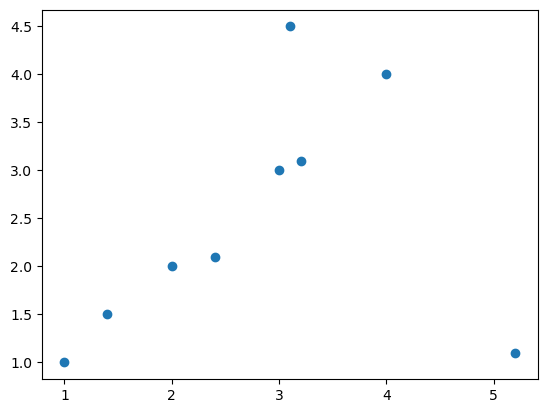

In [3]:
data = np.array(
    [
        [1, 1],
        [1.4, 1.5],
        [2.4, 2.1],
        [2, 2],
        [3, 3],
        [3.2, 3.1],
        [5.2, 1.1],
        [4, 4],
        [3.1, 4.5],
    ]
)
Xs = data[:, 0]
Ys = data[:, 1]

plt.scatter(Xs, Ys)

In [4]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x: np.ndarray):
    local_x = x.copy()
    local_x[x <= 0] = 0
    local_x[x > 0] = 1
    return local_x


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def get_activation_function(activation_name: str):
    if activation_name == "relu":
        return relu
    if activation_name == "sigmoid":
        return sigmoid

    raise RuntimeError(f"No activation with name {activation_name}")


def get_activation_function_derivative(activation_name: str):
    if activation_name == "relu":
        return relu_derivative

    raise RuntimeError(f"No activation with name {activation_name}")


In [5]:
# nn_architecture = [
#     {"input_dim": 2, "output_dim": 17, "activation": "relu"},
#     {"input_dim": 17, "output_dim": 3, "activation": "relu"},
#     {"input_dim": 3, "output_dim": 5, "activation": "relu"},
#     {"input_dim": 5, "output_dim": 2, "activation": "relu"},
# ]


nn_architecture = [
    {"input_dim": 1, "output_dim": 3, "activation": "relu"},
    {"input_dim": 3, "output_dim": 8, "activation": "relu"},
    {"input_dim": 8, "output_dim": 1, "activation": "relu"},
]


def layer_name(layer_index: int):
    return f"layer{layer_index}"


parameters = {}
for i, layer in enumerate(nn_architecture):
    parameters[layer_name(i)] = {"weights": np.random.randn(layer["output_dim"], layer["input_dim"]), "bias": np.random.randn(layer["output_dim"], 1)}


memory = {}


def forward(input):
    input_numpy = np.array(input)
    assert len(input_numpy.shape) == 1
    assert input_numpy.shape[0] == nn_architecture[0]["input_dim"]
    input_numpy = input_numpy.reshape(-1, 1)

    memory[layer_name(-1)] = {"after_activation": input_numpy}

    previous_output = input_numpy

    for i, layer in enumerate(nn_architecture):
        layer_parameters = parameters[layer_name(i)]
        before_activation = np.dot(layer_parameters["weights"], previous_output) + layer_parameters["bias"]
        activation = get_activation_function(layer["activation"])
        after_activation = activation(before_activation)
        memory[layer_name(i)] = {"before_activation": before_activation, "after_activation": after_activation}
        previous_output = after_activation

    return previous_output


gradient = {}


def backward(loss):
    gradient = {}

    # gradient without last term
    almost_gradient = {}

    # Keep in mind that we are going backwards! The variable i will decrease!
    for i, layer in reversed(list(enumerate(nn_architecture))):
        previous_layer_memory = memory[layer_name(i - 1)]

        current_layer_memory = memory[layer_name(i)]

        next_layer_parameters = parameters.get(layer_name(i + 1))
        if next_layer_parameters is None:
            next_layer_parameters = {"weights": np.array(1)}

        next_layer_almost_gradient = almost_gradient.get(layer_name(i + 1))
        if next_layer_almost_gradient is None:
            next_layer_almost_gradient = loss

        activation = get_activation_function_derivative(layer["activation"])
        current_after_derivative = activation(current_layer_memory["before_activation"])

        current_intermediate = np.dot(next_layer_almost_gradient.T, next_layer_parameters["weights"]).T

        # Here broadcasting is happening
        current_almost_gradient = np.multiply(current_after_derivative, current_intermediate)
        almost_gradient[layer_name(i)] = current_almost_gradient

        gradient[layer_name(i)] = np.dot(current_almost_gradient, previous_layer_memory["after_activation"].T)

    return gradient


# Y_hat = forward([1, 2])
# Ys = np.array([4, 4]).reshape(Y_hat.shape)
# loss = Ys - Y_hat
# gradient = backward(loss)

# print(parameters["layer1"]["weights"].shape)
# print(gradient["layer1"].shape)

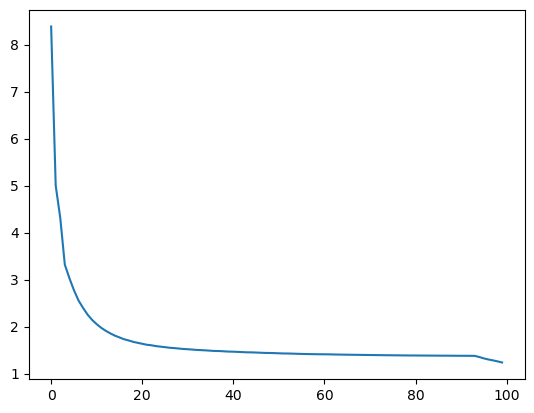

In [6]:
l = []


def train():
    lr = 0.01

    ll = 0
    for X, Y in zip(Xs, Ys):
        Y_hat = forward(X.reshape(1))
        loss = Y - Y_hat
        ll += loss.sum() * loss.sum()
        gradient = backward(loss)
        for layer in gradient:
            parameters[layer]["weights"] += lr * gradient[layer]

    ll /= len(Xs)
    l.append(ll)


for _ in range(100):
    train()

plt.plot(l)